# This notebook performs the one instruction EM stitch to create Alpha, Bravo, Charlie, Delta, and Echo in a similar fold style system.
- This is for comparison reasons to provide comparison to our ResGANs style of generation.

In [1]:
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import random
import tensorflow as tf
import numpy as np
import timeit
from sklearn.neighbors import NearestNeighbors
from sklearn import metrics
import scipy.io as sio
import csv
import os
import math 
import random as rand
from numpy import genfromtxt
from numpy import sum,isrealobj,sqrt
from numpy.random import standard_normal
from keras.models import load_model

#import torch
#from torch import nn

import warnings
from scipy.spatial import distance



import sys
sys.path.append("..") # Adds higher directory to python modules path.

from Modules.Tools import MapTool
from Modules.Tools import BoxPlot
from Modules.Tools import peakCorrelation as pC

In [2]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 1637233762214025031
 xla_global_id: -1]

In [3]:
params = {'legend.fontsize': 50,
          'figure.figsize': (45, 15),
         'axes.labelsize': 60,
         'axes.titlesize':70,
         'xtick.labelsize':50,
         'ytick.labelsize':50,
          'font.weight': "bold",
         'lines.linewidth': 5}
plt.rcParams.update(params)

# Notebook Parameters
- this is simply for obtaining the graphs with manual mapping. Pad is closely relate to the sampling rate for the EM signal

In [4]:
pad = 8

# Setup Save information

In [5]:
Save_Gen = "./Results/One_Inst_Stitching/"

# Load Dataset

In [6]:
load_Dataset_Folder = "./Datasets/FP_GANs_LargeScale_2/k-Fold/TrainingDatasets/"

In [7]:
alpha = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/full/Alpha/Alpha_full.npy", allow_pickle=True)

### Note the code is given as the string names for simple comparison and look up later on.

In [11]:
TS_1_Inst = np.load("./Datasets/Extracted Sequences/TS_1_Inst.npy", allow_pickle = True)

In [15]:
Alpha_1_seq_Info = np.load("./Datasets/Extracted Sequences/Generating/Alpha_1_seq_Info.npy", allow_pickle = True)

In [16]:
def createBaseCodeNames(Info):
    Base = []
    for seq in Info:
        code = seq["Code"]
        tokens = code
        token_list = []
        token_list.append(tokens[0])
        Base.append(token_list)
    return np.array(Base)

In [17]:
Alpha_Base_Code = createBaseCodeNames(Alpha_1_seq_Info)

In [19]:
print(Alpha_Base_Code.tolist())

[['ori'], ['stsPT1'], ['stsPT2'], ['ldsPT1'], ['ldsPT2'], ['ori'], ['mov'], ['andi'], ['mov'], ['ori'], ['mov'], ['andi']]


# Get the Major peaks of the baseline.

In [20]:
'''
Method extracts the sequence of code that would be from the middle point before the first instruction and after the last
instruction
'''
def extract(Signal, midpoint):
    instEM = np.copy(Signal)
    
    done = 0
    while done == 0:
        if instEM[0] < midpoint:
            instEM = instEM[1:]
        else:
            done = 1
    
    ## remove from the end of signal
    done = 0
    while done == 0:
        if instEM[instEM.shape[0]-1] > midpoint:
            instEM = instEM[:instEM.shape[0]-2]
        else:
            done = 1
    
    return instEM

In [21]:
'''
This method will take EM signals' major peaks and stitch them together in the order given returning 1 EM signal of major peaks only.

dataset: a 2D numpy array of the generated EM signals to be stitched together.
amount: amount of instruction contained in the EM signal
pad: The padding amount that referse to the amount of time index it takes to complete half a peak to peak interval
midpoint: the common mid or avg point between the high and low peaks. (if no preprocessing on signals it will be 0,
if normalized then it will be 0.5)
'''
def EMstitching_Peaks(dataset, amount, pad, midpoint):
    # list of EMs to stitch together.
    first = True
    # cycle through the dataset
    for n in range(dataset.shape[0]):
        signal_Major_Peaks = dataset[n]["Seq"]
        code = dataset[n]["Code"]
        
        # obtain the EM of the important instruction from generated EM sequence of instructions
        ## Not necessary as we switched to generative model only producing the last instructions EM.
        EM = signal_Major_Peaks
        
        # stitch together into one EM
        if first == True:
            EMFinal = np.copy(EM)
            first = False
        else:
            EMFinal = np.concatenate((EMFinal, EM))
    
    EMFinal = np.array(EMFinal)
    return EMFinal

In [22]:
def getMajorPeaksDatabase(program, start_peak, end_peak):
    # Obtain only the major peaks in the program signal
    Baseline = []
    ## extract the sequence of the program from the full signal
    for n in range(program.shape[0]):
        Baseline.append(extract(program[n][MapTool.getPeaksLoc(program[n], pad, start_peak, False): MapTool.getPeaksLoc(program[n], pad, end_peak)], 0))

    ## extract the peaks only
    Baseline_peaks = MapTool.getPeaksDataset(Baseline, pad)
    ## remove the end peak
    Baseline_peaks = Baseline_peaks[:,:Baseline_peaks.shape[1]-1]

    ## obtain only the major peaks removing the inbetween low peak.
    Baseline = []
    for n in range(Baseline_peaks.shape[0]):
        major_peaks = []
        for q in range(Baseline_peaks[n].shape[0]):
            if q%2 == 0:
                major_peaks.append(Baseline_peaks[n][q])
        Baseline.append(major_peaks)

    Baseline = np.array(Baseline, dtype=object)
    
    return Baseline

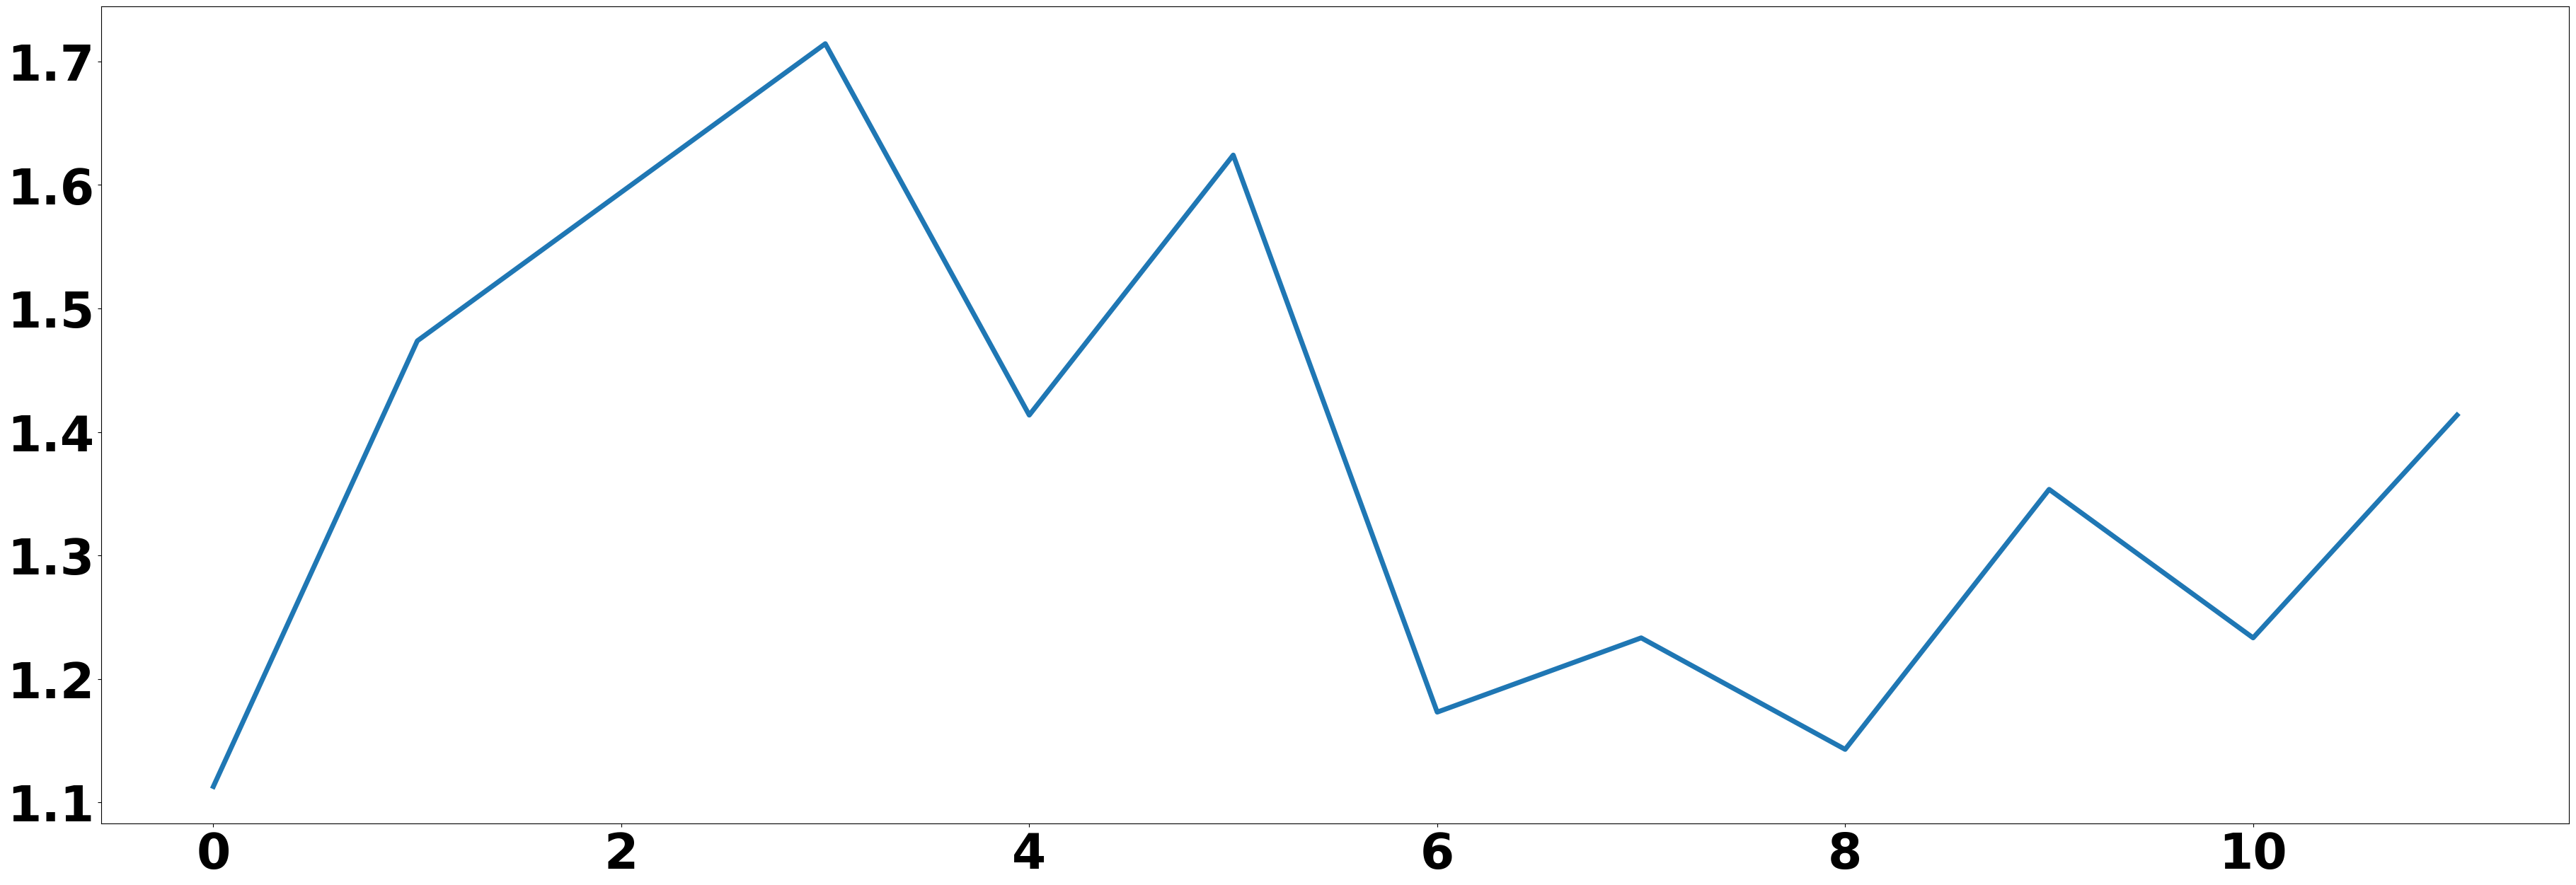

In [23]:
alpha_MPs = getMajorPeaksDatabase(alpha, 24, 48)
plt.plot(alpha_MPs[0])
plt.show()

# EM Stitching Method
- We have the code by names and a database of EM major peaks to stitch together to create a EM or major peaks similar to what is generated via ResGANs.
- As such, we can simply create a method to look at what the code is, pull random samples, then stitch together in a collective EM signal.

In [29]:
'''
DEFINITION: Method performs EM stitching of EM signals or peaks.

code: code given via names.
TS_to_Gen: Training set containing a dictionary of sequence/EM signals,code pairs.
amount: amount of signals to create
'''
def EMStitch(full_code, TS_to_Gen, amount):
    seqs = []
    for code in full_code:
        seq = []
        for info in TS_to_Gen:
            if info["Code"] == code:
                for n in range(amount):
                    loc = random.randint(0, info["Seq"].shape[0]-1)
                    seq.append(info["Seq"][loc][0])
                seqs.append(seq)
    
    seqs = np.array(seqs)
    seqs = np.reshape(seqs, (seqs.shape[0], seqs.shape[1],1))
    print(seqs.shape)
        
    gen_Signals = seqs[0]
    for s in range(len(full_code)-1):
        gen_Signals = np.concatenate((gen_Signals, seqs[s+1]), axis=1)
    
    return np.array(gen_Signals)          

In [31]:
EM_Stitch_Alpha = EMStitch(Alpha_Base_Code, TS_1_Inst, 1500)
np.save(Save_Gen + "EM_Stitch_Alpha.npy", EM_Stitch_Alpha)

(12, 1500, 1)


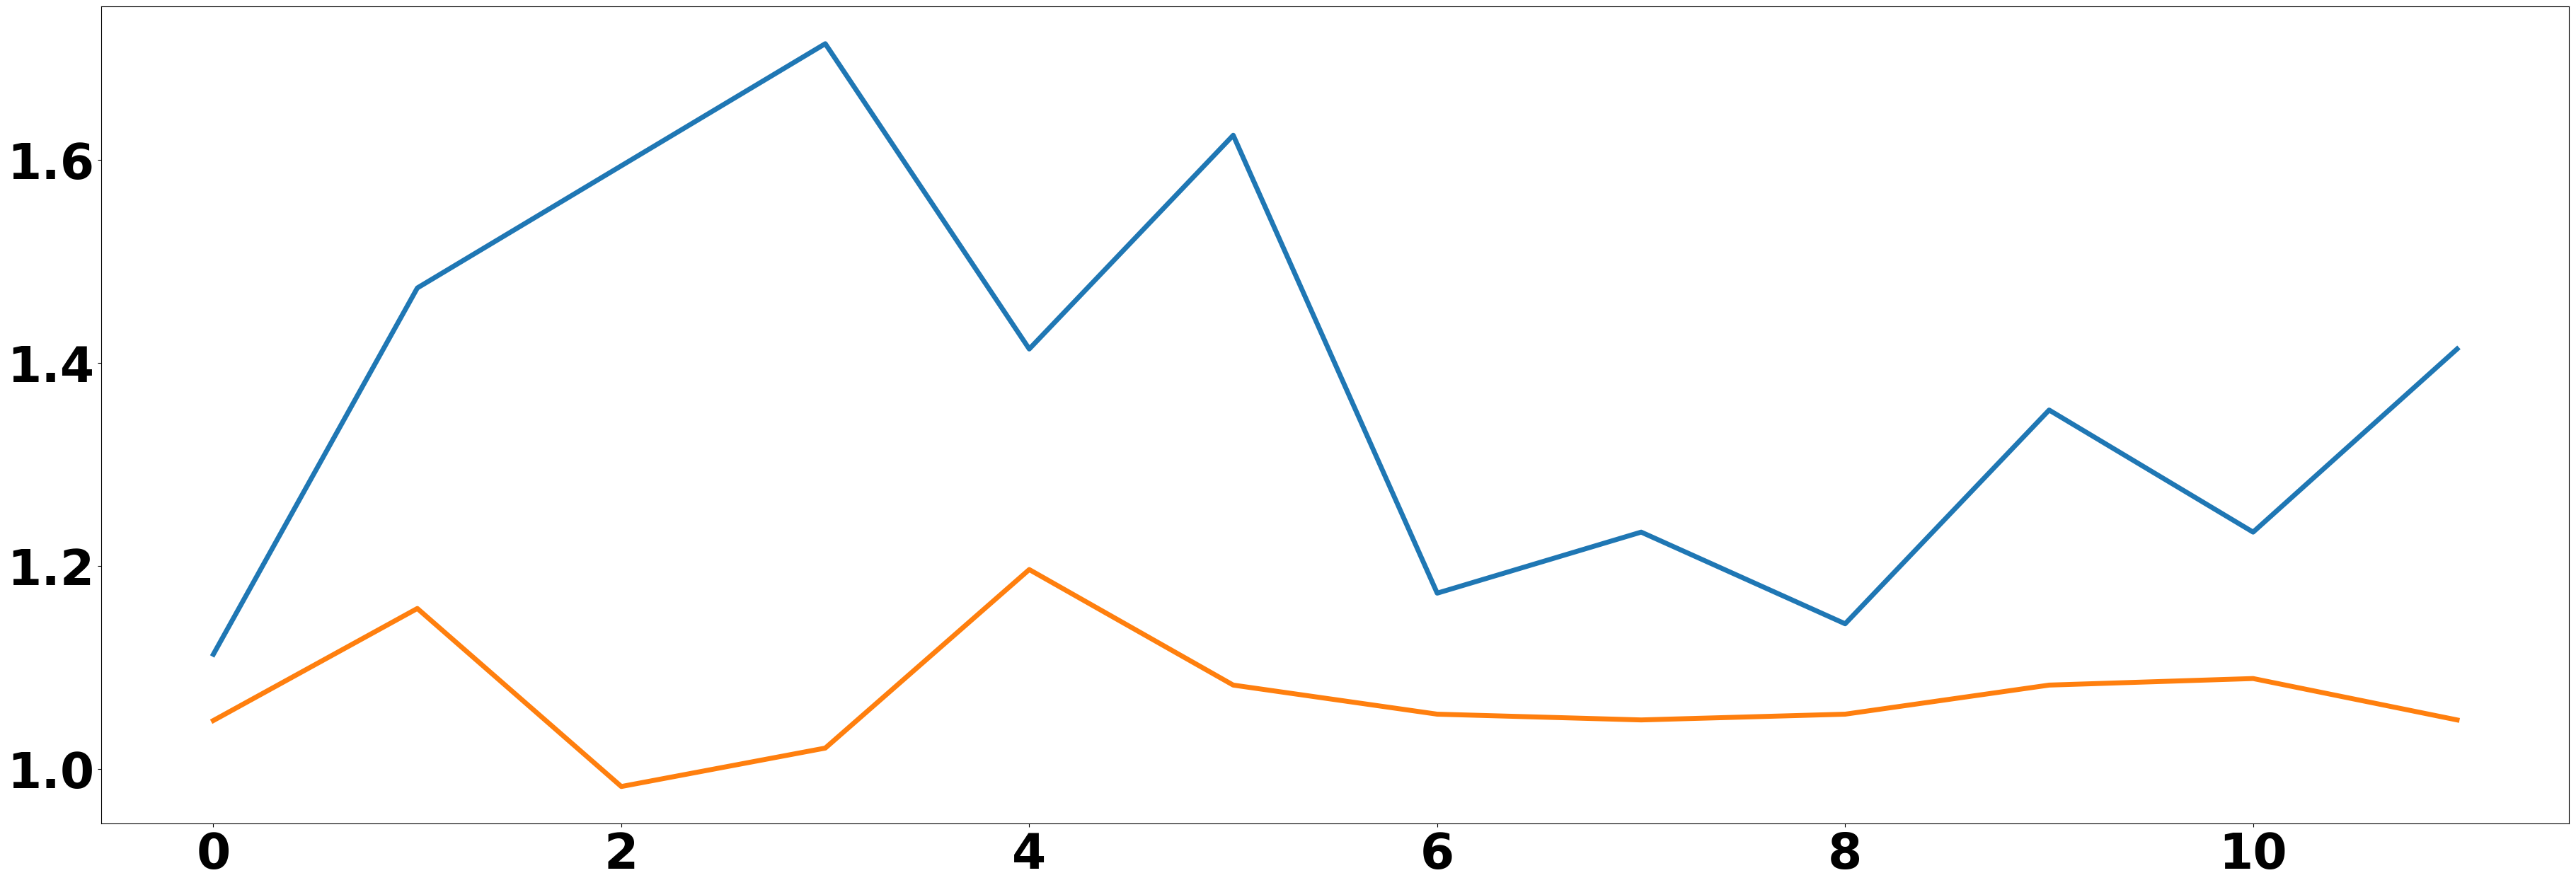

In [32]:
plt.plot(alpha_MPs[0])
plt.plot(EM_Stitch_Alpha[0])
plt.show()